# Morphology and expression in one model

**Day 3 · Session 8.1**

Every Visium slide comes with an H&E image. Most analyses use it once, to place the spots, and
never look at it again. The image is measured data: a pathologist can find the hippocampus on it
without a single read.

This notebook turns the tissue under each spot into numbers with a pathology foundation model,
then fits factor models to expression alone, to the image alone, and to both together. The
question throughout is which signal the two modalities share, which each has alone, and which of
it is biology rather than the slide or the sequencing depth.

### What you will be able to do afterwards

- Crop exactly the tissue a spot measured and hand it to a pathology model
- Normalise Visium counts deliberately, and check whether library size is itself spatial
- Fit and read a multi-view factor model: shared factors, view-specific factors, variance explained
- Compare separate and joint models, with a shuffled view as the negative control
- Put factor scores back into `SpatialData` and plot them on the tissue

## Setup

In [1]:
%matplotlib inline

import pathlib
import sys

# Find the repository root (the directory holding paths.py) and make it importable.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "paths.py").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import time

import anndata as ad
import matplotlib.pyplot as plt
import mofaflex as mfl
import mudata as md
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # noqa: F401
import squidpy as sq
from matplotlib.colors import CenteredNorm
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import adjusted_rand_score
from spatialdata.models import TableModel

import paths

CKPT = ROOT / "notebooks" / "day_3" / "checkpoints"

sdata = sd.read_zarr(paths.data("visium_hne.zarr"))
adata = sdata["adata"]
sdata

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



SpatialData object, with associated Zarr store: /Users/tim.treis/physalia_data/visium_hne.zarr
├── Images
│     └── 'hne': DataTree[cyx] (3, 11757, 11291), (3, 5878, 5645), (3, 2939, 2822), (3, 1469, 1411)
├── Shapes
│     └── 'spots': GeoDataFrame shape: (2688, 2) (2D shapes)
└── Tables
      └── 'adata': AnnData (2688, 18078)
with coordinate systems:
    ▸ 'global', with elements:
        hne (Images), spots (Shapes)

Three elements: the H&E image `hne` at four resolutions, the 2,688 spots as circles, and a table
with whole-transcriptome expression. The table carries a `cluster` annotation with anatomical
names. It ships next to `leiden` and `rank_genes_groups`, and `leiden` and `cluster` agree
perfectly, so `cluster` is the expression clustering with its clusters renamed. Treat it as
**expression-derived labels**, not as independent ground truth: an image feature that disagrees
with `cluster` disagrees with expression, and that is not the same as being wrong.

In [3]:
print(f"adjusted Rand index, leiden vs cluster: {adjusted_rand_score(adata.obs['leiden'], adata.obs['cluster']):.2f}")
adata.obs["cluster"].value_counts()

adjusted Rand index, leiden vs cluster: 1.00


cluster
Cortex_1                         284
Thalamus_1                       261
Cortex_2                         257
Cortex_3                         244
Fiber_tract                      226
Hippocampus                      222
Hypothalamus_1                   208
Thalamus_2                       192
Cortex_4                         164
Striatum                         153
Hypothalamus_2                   133
Cortex_5                         129
Lateral_ventricle                105
Pyramidal_layer_dentate_gyrus     68
Pyramidal_layer                   42
Name: count, dtype: int64

## 1. The tissue behind a spot

A Visium spot is 55 µm across ([10x Genomics](https://www.10xgenomics.com/products/spatial-gene-expression)).
The spots are stored in image pixel coordinates, so their radius gives the image resolution
directly.

In [4]:
spots = sdata["spots"]
um_per_px = 55 / (2 * spots["radius"].median())
print(f"spot radius {spots['radius'].median():.1f} px  ->  {um_per_px:.2f} µm per pixel")

# spot centres, in the same order as the table
adata.obsm["spatial"] = np.c_[spots.geometry.x, spots.geometry.y][adata.obs["spot_id"].to_numpy()]


def zoom_to_tissue(ax, pad=100):
    # crop a map to the spots, hiding the empty slide and fiducial frame around the section
    x, y = adata.obsm["spatial"].T
    ax.set_xlim(x.min() - pad, x.max() + pad)
    ax.set_ylim(y.max() + pad, y.min() - pad)
    ax.axis("off")

spot radius 37.8 px  ->  0.73 µm per pixel


Each tile is the **bounding box of one spot** and nothing more: 76 px, 55 µm, centred on the
spot. Visium spots sit 100 µm apart centre to centre, so neighbouring tiles never overlap and
every tile shows only tissue that its own spot measured (plus the four corners the circle does
not cover).

H-optimus-0, the model used below, takes 224 × 224 px tiles and was trained at 0.5 µm per pixel
([Bioptimus model card](https://huggingface.co/bioptimus/H-optimus-0)). Resizing a 76 px crop to
224 px shows it the tissue at about **0.25 µm per pixel** — twice its training magnification, and
blurrier, because upsampling adds pixels but no detail. We accept that in exchange for tiles
that match the spots exactly.

A spot holds on the order of a few to ten cells, so a tile is a small patch of tissue with those
cells in it, not the morphology of any single cell.

In [5]:
CROP_PX = round(2 * spots["radius"].median())  # bounding box of the spot circle
hne = sdata["hne"]["scale0"]["image"]


def tile(i, size=CROP_PX):
    # H&E crop centred on spot i, as (y, x, rgb)
    x, y = np.round(adata.obsm["spatial"][i]).astype(int)
    h = size // 2
    return hne.isel(y=slice(y - h, y - h + size), x=slice(x - h, x - h + size)).transpose("y", "x", "c").values


print(f"crop {CROP_PX} px = {CROP_PX * um_per_px:.0f} µm of tissue, shown to the model at {CROP_PX * um_per_px / 224:.2f} µm/px")

crop 76 px = 55 µm of tissue, shown to the model at 0.25 µm/px


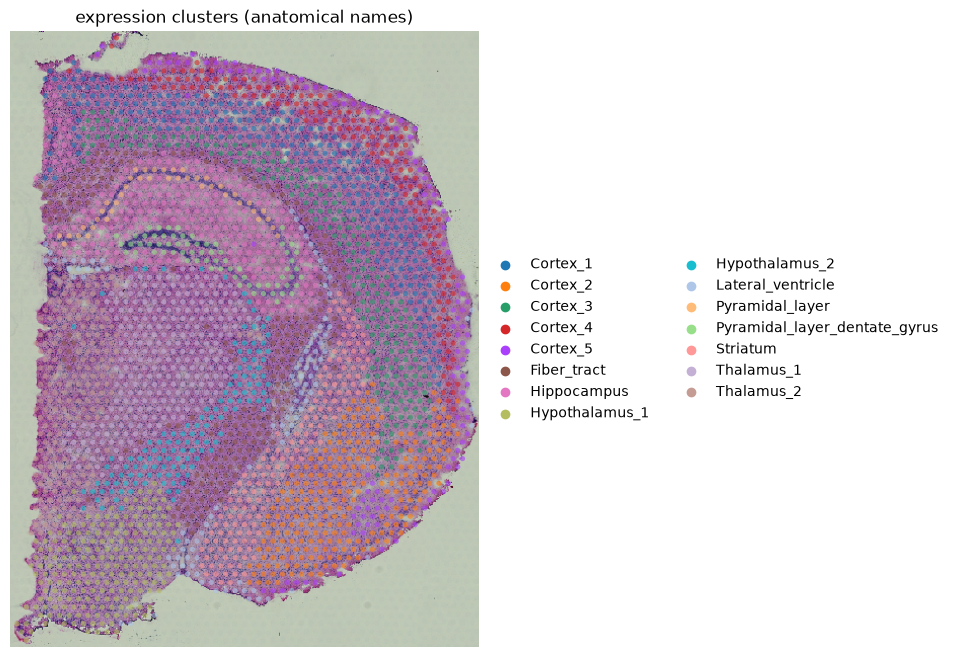

In [6]:
fig, ax = plt.subplots(figsize=(9, 8))
sdata.pl.render_images("hne").pl.render_shapes("spots", color="cluster", table_name="adata", fill_alpha=0.6).pl.show(
    ax=ax, coordinate_systems="global", title="expression clusters (anatomical names)"
)
zoom_to_tissue(ax)
plt.show()

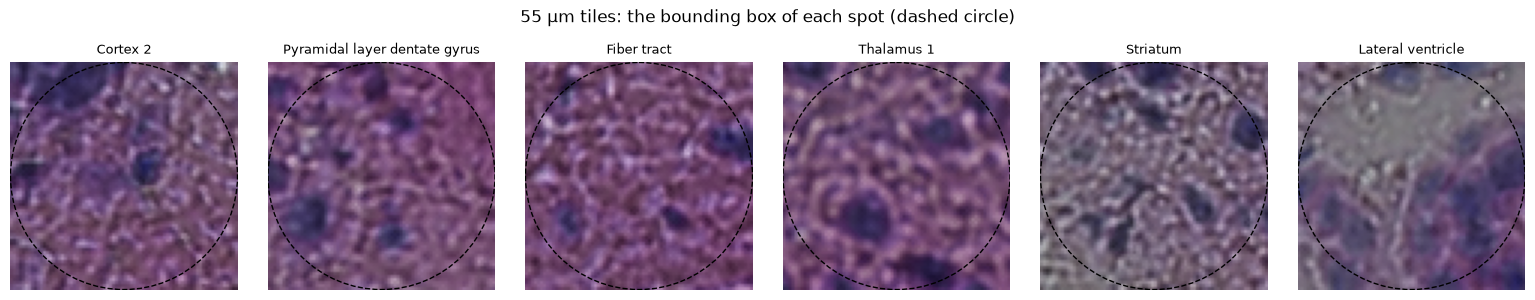

In [7]:
regions = ["Cortex_2", "Pyramidal_layer_dentate_gyrus", "Fiber_tract", "Thalamus_1", "Striatum", "Lateral_ventricle"]
rng = np.random.default_rng(0)

fig, axs = plt.subplots(1, len(regions), figsize=(2.6 * len(regions), 2.9))
for ax, region in zip(axs, regions):
    i = rng.choice(np.flatnonzero(adata.obs["cluster"] == region))
    ax.imshow(tile(i))
    ax.add_patch(plt.Circle((CROP_PX / 2 - 0.5, CROP_PX / 2 - 0.5), spots["radius"].median(), fill=False, color="black", lw=1, ls="--"))
    ax.set_title(region.replace("_", " "), fontsize=9)
    ax.axis("off")
plt.suptitle(f"{CROP_PX * um_per_px:.0f} µm tiles: the bounding box of each spot (dashed circle)", y=1.02)
plt.tight_layout()
plt.show()

> **_Question:_** Which of these regions would you trust yourself to recognise from a 55 µm
> patch alone? Which look the same to you?

## 2. Features from a pathology foundation model

Every tile went through H-optimus-0, a 1.1-billion-parameter vision transformer trained on
human histopathology. Each tile becomes a vector of 1,536 numbers. The embeddings were computed
once, by `scripts/precompute_hne_embeddings.py`, and are loaded here: running a model this size
for 25 people on a CPU server would take the whole session.

Two things to hold on to before trusting these features:

- **Domain shift.** The model has never seen mouse brain, and it sees these tiles at twice its
  training magnification. Whatever it recovers here, it recovers despite both.
- **No labels went in.** The model was not told about brain regions or expression. Structure in
  the embedding comes from the pixels.

In [8]:
(emb_path,) = sorted(CKPT.glob("visium_hne_*_embeddings.npz"))
z = np.load(emb_path, allow_pickle=False)
print(emb_path.name, "|", str(z["model"]), "|", z["embedding"].shape, z["embedding"].dtype, f"| {int(z['crop_px'])} px tiles")

order = pd.Index(z["spot_id"]).get_indexer(adata.obs["spot_id"].astype(str))
img = ad.AnnData(z["embedding"][order].astype(np.float32), obs=adata.obs[["cluster"]].copy())
img.obsm["spatial"] = adata.obsm["spatial"]
img

visium_hne_hoptimus0_embeddings.npz | bioptimus/H-optimus-0 | (2688, 1536) float16 | 76 px tiles


AnnData object with n_obs × n_vars = 2688 × 1536
    obs: 'cluster'
    obsm: 'spatial'
    layers: None (.X)

Treat the embedding like any other feature matrix: scale, reduce, build a neighbour graph,
cluster. Nothing about this step knows that the features came from an image, or where the spots
are.

In [9]:
sc.pp.scale(img)
sc.pp.pca(img, n_comps=50)
sc.pp.neighbors(img, n_neighbors=15)
sc.tl.leiden(img, resolution=1.0, flavor="igraph", n_iterations=2, key_added="img_leiden")
adata.obs["img_leiden"] = pd.Categorical(img.obs["img_leiden"].to_numpy())
print(f"{img.obs['img_leiden'].nunique()} image clusters")
print(f"adjusted Rand index, image clusters vs expression clusters: {adjusted_rand_score(adata.obs['cluster'], adata.obs['img_leiden']):.2f}")

11 image clusters
adjusted Rand index, image clusters vs expression clusters: 0.17


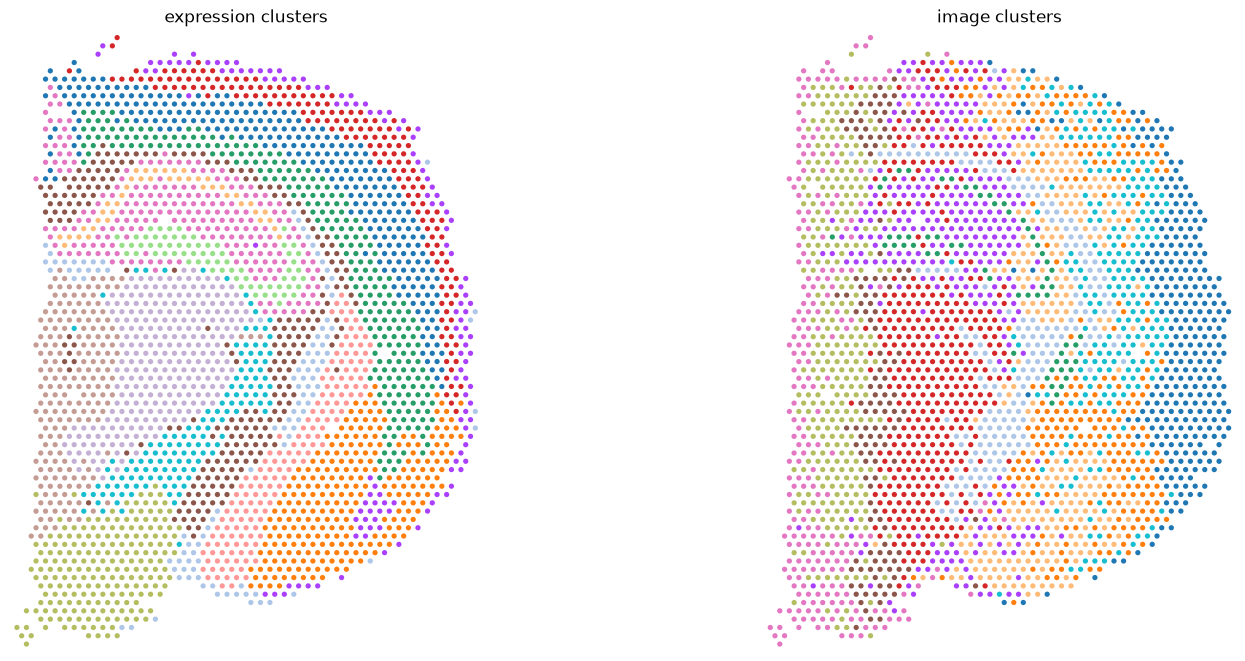

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6.5), layout="constrained")
for ax, key, title in zip(axs, ["cluster", "img_leiden"], ["expression clusters", "image clusters"]):
    sdata.pl.render_shapes("spots", color=key, table_name="adata").pl.show(ax=ax, title=title, coordinate_systems="global", legend_loc=None)
    zoom_to_tissue(ax)
plt.show()

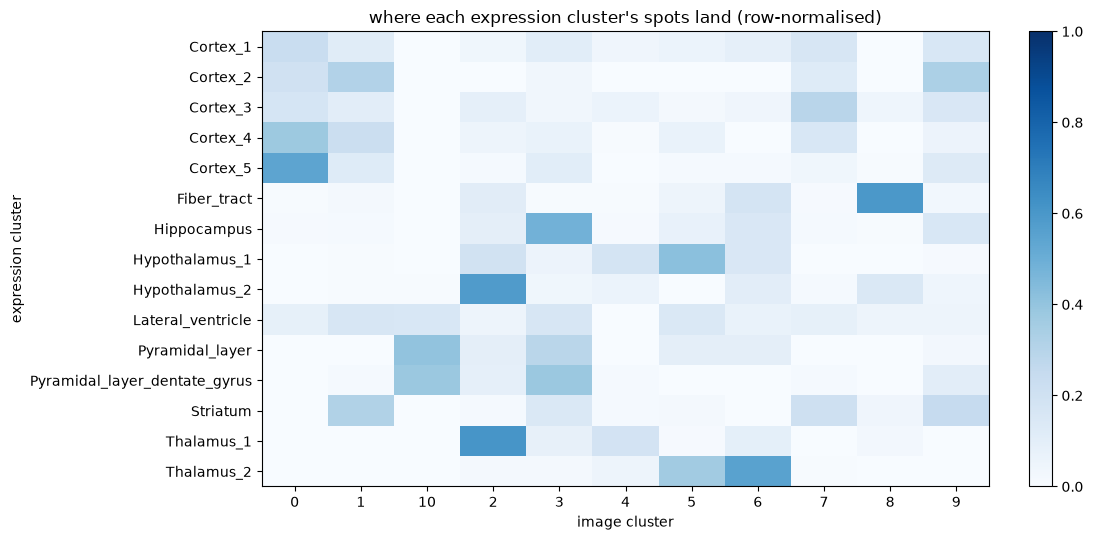

In [11]:
ct = pd.crosstab(adata.obs["cluster"], adata.obs["img_leiden"], normalize="index")

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(ct.to_numpy(), cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set(xticks=range(ct.shape[1]), xticklabels=ct.columns, yticks=range(ct.shape[0]), yticklabels=ct.index)
ax.set(xlabel="image cluster", ylabel="expression cluster", title="where each expression cluster's spots land (row-normalised)")
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()

The image clusters are spatially coherent even though neither coordinates nor labels went into them: neighbouring spots look alike, so they cluster together. Against the expression clusters the adjusted Rand index is 0.17 — structure, but a different partition.

Where they agree:

- **Fiber tract** is the cleanest case. 60% of its spots fall in one image cluster, and that cluster is 73% fiber tract. Myelinated white matter looks different from everything else on H&E.
- **Thalamus_1 (61%), Hypothalamus_2 (58%) and Thalamus_2 (55%)** each concentrate in one image cluster.
- The **hippocampal pyramidal and dentate layers** land together in a small 60-spot cluster, alongside spots labelled lateral ventricle. Expression separates those layers; a 55 µm patch of densely packed nuclei does not.

Where they do not:

- **The cortex is split by position, not by layer.** The rightmost image cluster holds 302 spots with Cortex_5, Cortex_1, Cortex_4 and Cortex_2 in nearly equal parts; three further clusters mix cortical layers at other distances across the section. Cortical layers differ in expression more than a small H&E patch shows.
- **Lateral ventricle** is the weakest: no image cluster holds more than 16% of its spots.

Agreement is the expected part. The disagreements are what §5 has to explain, and the clusters that track position across the slide are the first thing to be suspicious of.

## 3. Expression, from raw counts

The table's `.X` is already log-normalised, but by an unrecorded recipe: it does not match the
standard `normalize_total(target_sum=1e4)` + `log1p` applied to the raw counts. Rather than
inherit a preprocessing we cannot describe, we start again from `.raw`, and first look at the
quantity normalisation removes.

In [12]:
counts = adata.raw.to_adata()
recipe = counts.copy()
sc.pp.normalize_total(recipe, target_sum=1e4)
sc.pp.log1p(recipe)
print(f"raw counts: {counts.shape}, integer: {bool(np.allclose(counts.X[:100].toarray(), np.round(counts.X[:100].toarray())))}")
print(f"max |shipped .X - log1p(normalize_total(raw, 1e4))| = {abs(recipe.X - adata.X).max():.2f}")

raw counts: (2688, 18078), integer: True
max |shipped .X - log1p(normalize_total(raw, 1e4))| = 1.00


In [13]:
library_size = np.asarray(counts.X.sum(axis=1)).ravel()
adata.obs["log10_library_size"] = np.log10(library_size)
adata.obs["pct_mito"] = 100 * np.asarray(counts[:, counts.var["mt"].to_numpy()].X.sum(axis=1)).ravel() / library_size

# Moran's I on the 6 nearest spots: 1 = neighbours identical, 0 = no spatial pattern
sq.gr.spatial_neighbors_knn(adata, n_neighs=6)
sq.gr.spatial_autocorr(adata, mode="moran", attr="obs", genes=["log10_library_size", "pct_mito"], n_perms=100, seed=0, show_progress_bar=False)
print(adata.uns["moranI"][["I", "pval_sim"]].round(3))

by_region = adata.obs.groupby("cluster", observed=True)
eta2 = (by_region["log10_library_size"].count() * (by_region["log10_library_size"].mean() - adata.obs["log10_library_size"].mean()) ** 2).sum() / (
    (adata.obs["log10_library_size"] - adata.obs["log10_library_size"].mean()) ** 2
).sum()
print(f"\nshare of log library-size variance explained by expression cluster: {eta2:.0%}")
(10 ** by_region["log10_library_size"].median()).round(-2).sort_values().rename("median library size")

INFO     Creating graph using `None` transform and `1` libraries.                                                  


                        I  pval_sim
pct_mito            0.584      0.01
log10_library_size  0.479      0.01

share of log library-size variance explained by expression cluster: 47%


cluster
Hippocampus                      14500.0
Cortex_5                         14700.0
Fiber_tract                      18900.0
Thalamus_1                       22300.0
Hypothalamus_2                   25100.0
Thalamus_2                       27500.0
Cortex_1                         30200.0
Lateral_ventricle                30600.0
Cortex_4                         31300.0
Cortex_2                         32600.0
Cortex_3                         35100.0
Hypothalamus_1                   38100.0
Striatum                         39800.0
Pyramidal_layer_dentate_gyrus    50100.0
Pyramidal_layer                  51300.0
Name: median library size, dtype: float32

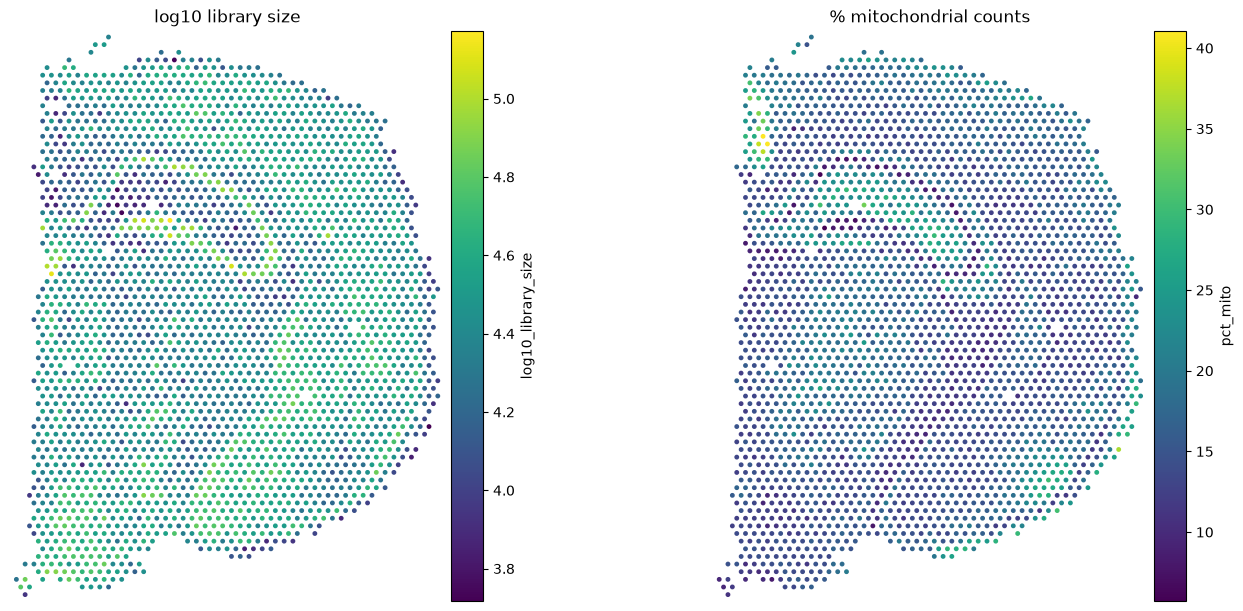

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6), layout="constrained")
for ax, key, title in zip(axs, ["log10_library_size", "pct_mito"], ["log10 library size", "% mitochondrial counts"]):
    sdata.pl.render_shapes("spots", color=key, table_name="adata", cmap="viridis").pl.show(ax=ax, title=title, coordinate_systems="global")
    zoom_to_tissue(ax)
plt.show()

Three things in these numbers.

- **The shipped `.X` is not the standard recipe.** Its largest deviation from `log1p(normalize_total(raw, 1e4))` is a full log unit.
- **Library size is spatial.** Moran's I is 0.48 for log library size and 0.58 for mitochondrial fraction (1 would mean neighbouring spots are identical). The permutation p-value of 0.01 is the smallest 100 permutations can give: no shuffle came close.
- **It follows the anatomy.** The expression clusters account for 47% of the variance in log library size. Median depth runs from about 14,500 counts in `Hippocampus` and `Cortex_5` to about 51,000 in the pyramidal and dentate layers — a factor of 3.5. Mitochondrial fraction runs the other way (Spearman ρ = −0.58 with library size): 10% in `Pyramidal_layer`, 23% in `Hippocampus` and `Cortex_5`, and 13 of the 16 spots above 30% are in `Hippocampus`.

The clusters were built from normalised expression, so they did not see depth directly, and they still line up with it. A mitochondrial threshold here would delete regions, not bad spots.

### What we do about it

Library size in Visium is not only a technical nuisance. It follows the tissue, so dividing it
out removes some biology along with the depth. SpaNorm was built for exactly this, and describes
the problem as a "spatial association between region-specific library size and biology"
([Salim, Bhuva et al., 2025](https://doi.org/10.1186/s13059-025-03565-y)); it is an R package.

In Python today we use the standard recipe and then **check** every factor for library size,
rather than assume normalisation took care of it:

1. **Size-factor normalisation to the median depth**, then `log1p` — the shifted logarithm, which
   performs as well as more elaborate transformations in a systematic comparison
   ([Ahlmann-Eltze & Huber, 2023](https://doi.org/10.1038/s41592-023-01814-1);
   [single-cell best practices](https://www.sc-best-practices.org/preprocessing_visualization/normalization.html)).
   The MOFA authors recommend the same for count data: "size factor normalisation + variance
   stabilisation" ([MOFA FAQ](https://biofam.github.io/MOFA2/faq.html)).
2. **2,000 highly variable genes**, chosen on the raw counts (`seurat_v3`). This also keeps the
   two views the same order of size — 2,000 genes against 1,536 image features — because "bigger
   data modalities will tend to be overrepresented in the factors" ([MOFA FAQ](https://biofam.github.io/MOFA2/faq.html)).
3. **Image features z-scored** one by one.

The function below is the exact preparation the shipped models were fitted on.

In [15]:
def build_mudata(adata, emb_path, shuffle=False, seed=42):
    # must stay identical to scripts/prefit_mofa_visium_hne.py
    # expression: raw counts -> median-depth normalisation -> shifted log -> 2000 HVGs chosen on counts
    rna = adata.raw.to_adata()
    rna.layers["counts"] = rna.X.copy()
    sc.pp.normalize_total(rna, target_sum=None)
    sc.pp.log1p(rna)
    sc.pp.highly_variable_genes(rna, flavor="seurat_v3", n_top_genes=2000, layer="counts")
    rna = rna[:, rna.var["highly_variable"].to_numpy()].copy()
    rna.X = rna.X.toarray()
    del rna.layers["counts"]

    # image: H&E foundation-model embedding per spot, each feature z-scored
    z = np.load(emb_path, allow_pickle=False)
    order = pd.Index(z["spot_id"]).get_indexer(adata.obs["spot_id"].astype(str))
    x = z["embedding"][order].astype(np.float32)
    x = (x - x.mean(axis=0)) / np.clip(x.std(axis=0), 1e-6, None)
    if shuffle:
        x = x[np.random.default_rng(seed).permutation(len(x))]

    img_view = ad.AnnData(x, obs=pd.DataFrame(index=adata.obs_names.copy()))
    img_view.var_names = [f"emb_{i}" for i in range(x.shape[1])]
    return md.MuData({"rna": rna, "img": img_view})


mdata = build_mudata(adata, emb_path)
mdata

MuData object with n_obs × n_vars = 2688 × 3536
  2 modalities
    rna:	2688 × 2000
      obs:	'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'region', 'spot_id', 'img_leiden', 'log10_library_size', 'pct_mito'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'pca', 'umap', 'spatialdata_attrs', 'neighbors', 'rank_genes_groups', 'hvg', 'leiden', 'leiden_colors', 'cluster_colors', 'spatial_neighbors', 'moranI', 'log1p'
      obsm:	'X_umap', 'X_pca', 'spatial'
      layers:

## 4. One model for both modalities

MOFA ([Argelaguet et al., 2020](https://doi.org/10.1186/s13059-020-02015-1)) decomposes each
view into the same set of factors — one score per spot per factor — and a weight per feature per
view. For every factor it reports the variance explained (R²) in each view. We use **MOFA-FLEX**
([Qoku et al., 2025](https://doi.org/10.1101/2025.11.03.686250)), the PyTorch successor that
reads `MuData` directly.

It is a linear model with readable weights. After Session 7, that is a feature: every factor can
be traced back to genes on one side and to tiles on the other.

Four models were fitted with identical preparation, 10 factors, the same seed and the same
options, by `scripts/prefit_mofa_visium_hne.py`:

| model | views | role |
|---|---|---|
| joint | expression + image | the model we read |
| joint, image shuffled | expression + image features permuted across spots | negative control |
| expression only | expression | what expression finds alone |
| image only | image | what the image finds alone |

Each takes several minutes on a laptop CPU, so we load them.

In [16]:
files = {"joint": "mofa_visium_hne", "joint_shuffled": "mofa_visium_hne_shuffled", "rna_only": "mofa_visium_hne_rna_only", "img_only": "mofa_visium_hne_img_only"}
models = {name: mfl.MOFAFLEX.load(CKPT / f"{f}.h5", map_location="cpu") for name, f in files.items()}
META = adata.uns["spatialdata_attrs"]  # region "spots", region_key "region", instance_key "spot_id"


def r2_table(m):
    # R² per factor (rows) and view (columns). ordered=True sorts factors by their R² summed
    # over views, so F1 explains the most variance overall — not necessarily in either one view.
    r = m.get_r2(ordered=True)["group_1"]
    r = r if r.shape[0] == m.n_factors else r.T
    assert list(r.index) == list(m.get_factors(ordered=True)["group_1"].columns), "factor order differs"
    return r.set_axis([f"F{i}" for i in range(1, len(r) + 1)], axis=0)


def factor_scores(m):
    f = m.get_factors(ordered=True)["group_1"].loc[adata.obs_names]
    return f.set_axis([f"F{i}" for i in range(1, f.shape[1] + 1)], axis=1)


def add_factor_table(name, scores):
    # one SpatialData table per model, annotating the same spots as the expression table
    t = ad.AnnData(
        scores.to_numpy(np.float32),
        obs=adata.obs[[META["region_key"], META["instance_key"]]].copy(),
        var=pd.DataFrame(index=scores.columns),
    )
    sdata.tables[name] = TableModel.parse(t, region=META["region"], region_key=META["region_key"], instance_key=META["instance_key"])


R2 = {name: r2_table(m) for name, m in models.items()}
F = {name: factor_scores(m) for name, m in models.items()}
for name, scores in F.items():
    add_factor_table(f"mofa_{name}", scores)

print({name: list(r.columns) for name, r in R2.items()})
list(sdata.tables)

{'joint': ['rna', 'img'], 'joint_shuffled': ['rna', 'img'], 'rna_only': ['rna'], 'img_only': ['img']}


['adata',
 'mofa_joint',
 'mofa_joint_shuffled',
 'mofa_rna_only',
 'mofa_img_only']

Two conventions before reading anything. Factors are renamed **F1…F10 in order of the variance
they explain summed over the two views**, so F1 is the largest axis overall, not the largest in
either view separately. And factor signs are arbitrary: a factor and its negative explain the
same variance, so red and blue mark opposite ends, not "high" and "low" of anything.

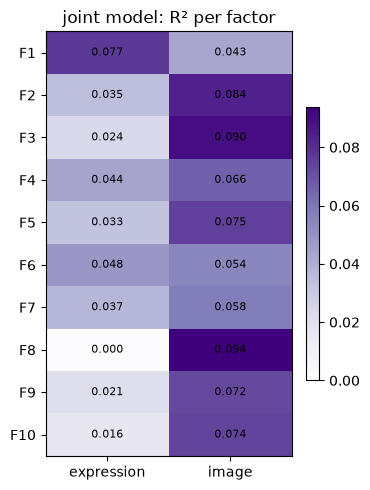

In [17]:
r2 = R2["joint"]

fig, ax = plt.subplots(figsize=(3.8, 5))
im = ax.imshow(r2[["rna", "img"]].to_numpy(), cmap="Purples", aspect="auto")
ax.set(xticks=[0, 1], xticklabels=["expression", "image"], yticks=range(len(r2)), yticklabels=r2.index)
for (i, j), v in np.ndenumerate(r2[["rna", "img"]].to_numpy()):
    ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=8)
ax.set_title("joint model: R² per factor")
plt.colorbar(im, ax=ax, fraction=0.05)
plt.tight_layout()
plt.show()

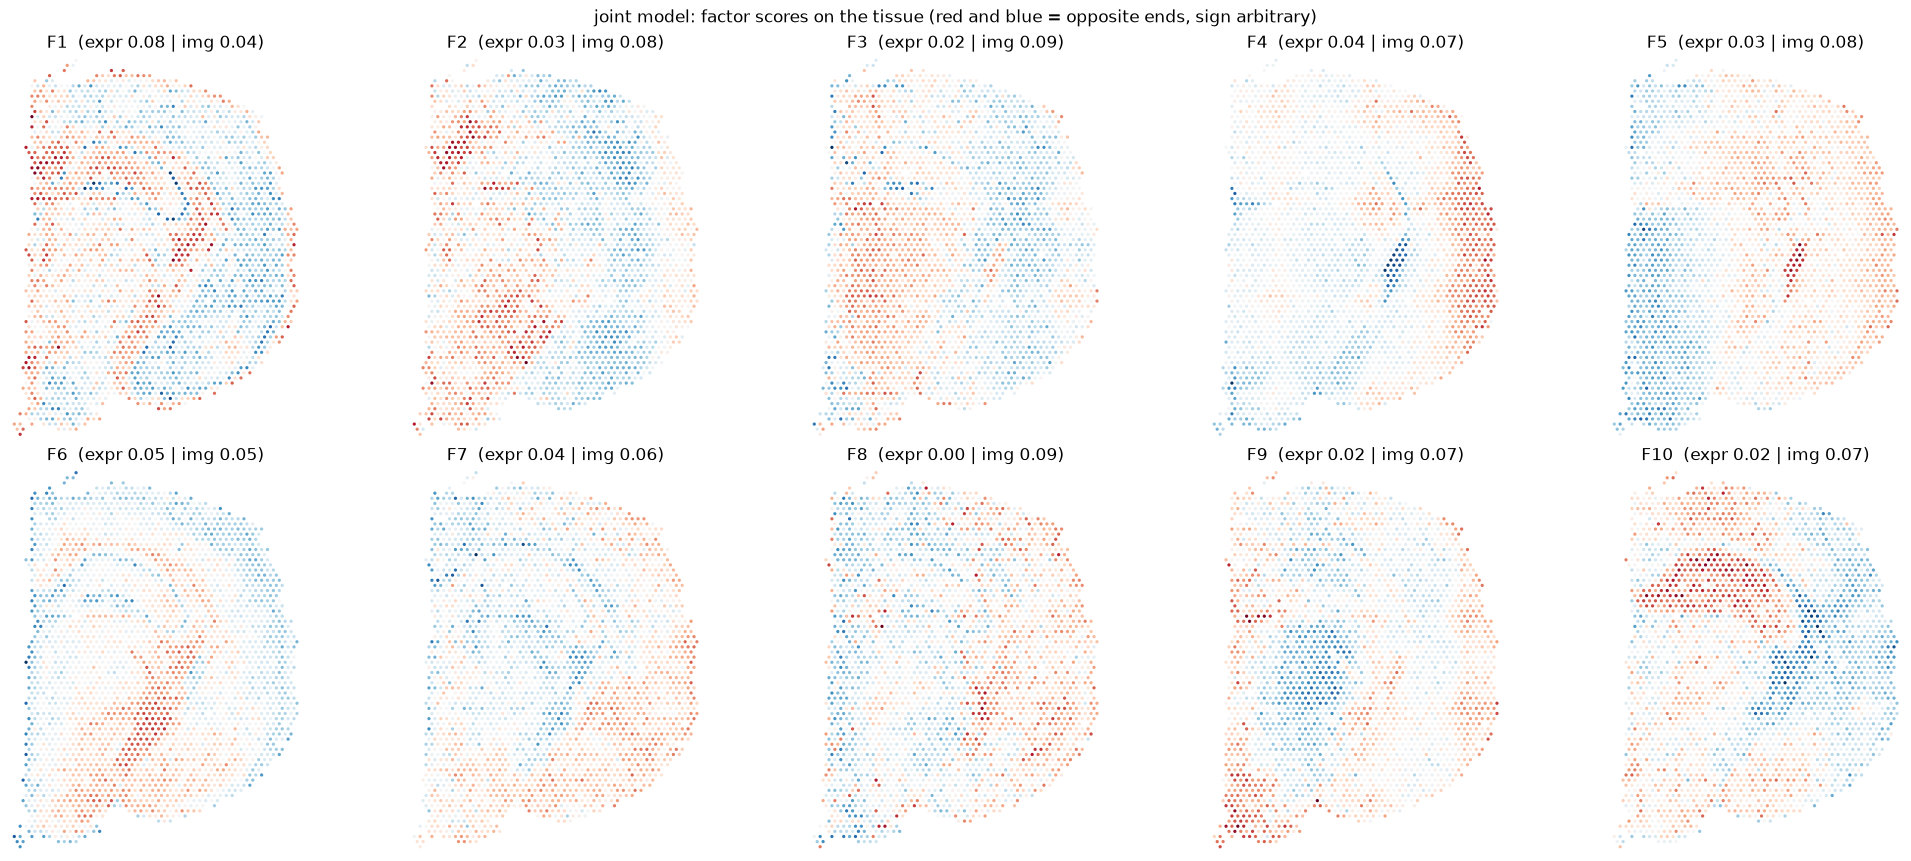

In [18]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8.5), layout="constrained")
for ax, f in zip(axs.ravel(), F["joint"].columns):
    sdata.pl.render_shapes("spots", color=f, table_name="mofa_joint", cmap="RdBu_r", norm=CenteredNorm()).pl.show(
        ax=ax, title=f"{f}  (expr {r2.loc[f, 'rna']:.2f} | img {r2.loc[f, 'img']:.2f})", coordinate_systems="global", colorbar=False
    )
    zoom_to_tissue(ax)
fig.suptitle("joint model: factor scores on the tissue (red and blue = opposite ends, sign arbitrary)")
plt.show()

Every factor explains between 4% and 9% of the image variance and between 0% and 8% of the expression variance, and each one is a recognisable spatial pattern rather than noise.

Some follow anatomy: F6 traces the fiber tracts, F9 fills the thalamus, F10 separates the cortical band from the structures beneath it. Others run across anatomy from one side of the section to the other — F5 most obviously, and F2, F3 and F4 to a lesser degree. §5.5 and the exercise put numbers on that second group.

F1 is worth noting now: it explains the most expression variance of any factor (R² 0.077) and its correlation with log library size is −0.64.

## 5. Separate or joint?

A joint model is only worth its complexity if fitting the views together finds something that
fitting them apart does not. Six checks, in order.

### 5.1 Variance explained, separate versus joint

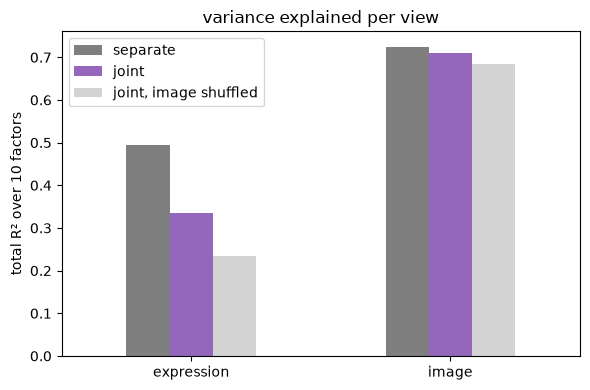

,separate,joint,"joint, image shuffled"
expression,0.495,0.335,0.234
image,0.725,0.710,0.685


In [19]:
ve = pd.DataFrame(
    {
        "separate": [R2["rna_only"]["rna"].sum(), R2["img_only"]["img"].sum()],
        "joint": [R2["joint"]["rna"].sum(), R2["joint"]["img"].sum()],
        "joint, image shuffled": [R2["joint_shuffled"]["rna"].sum(), R2["joint_shuffled"]["img"].sum()],
    },
    index=["expression", "image"],
)
ax = ve.plot.bar(figsize=(6, 4), rot=0, color=["tab:grey", "tab:purple", "lightgrey"])
ax.set(ylabel="total R² over 10 factors", title="variance explained per view")
plt.tight_layout()
plt.show()
ve.round(3)

Read the three columns as one comparison.

- On the **image** view, joint and separate are nearly the same (0.710 vs 0.725): fitting alongside expression costs the image almost nothing.
- On the **expression** view, the joint model explains 0.335 against 0.495 for expression alone. Ten factors shared between the views are not the same ten factors expression would choose for itself.
- The **shuffled control** still reaches 0.234 in expression and 0.685 in the image. A shuffled image view cannot share anything with expression, so this is the baseline any claim about sharing must beat.

Why expression loses variance in the joint fit is an open question: the image view has 1,536 features against 2,000 genes, but they are far more correlated with one another, so the two views do not weigh equally. A variant with the image reduced to a hundred components is being fitted separately to test that. Don't conclude anything about joint modelling in general from this one number.

### 5.2 Which factors are shared?

We call a factor **active** in a view when it explains at least **1% of that view's variance**
(R² ≥ 0.01). Active in both views: shared. Active in one: specific to it. The threshold is a
choice, and the shuffled model shows what "shared" looks like when nothing can be shared.

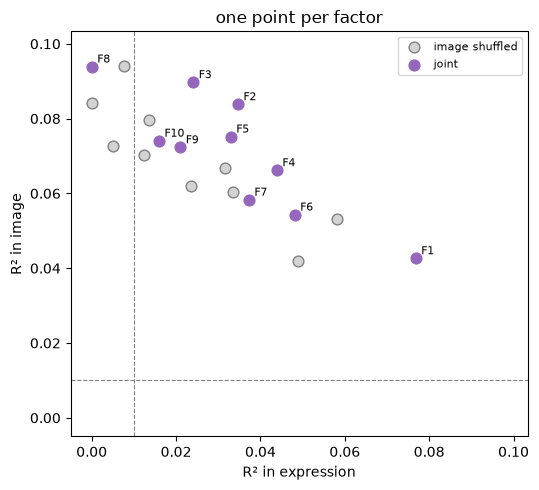

,joint,"joint, image shuffled"
shared,9,7
image-specific,1,3


In [20]:
ACTIVE = 0.01


def classify(r, thr=ACTIVE):
    return pd.Series(
        np.select([(r["rna"] >= thr) & (r["img"] >= thr), r["rna"] >= thr, r["img"] >= thr], ["shared", "expression-specific", "image-specific"], "inactive"),
        index=r.index,
    )


kinds = pd.DataFrame({"joint": classify(R2["joint"]), "joint, image shuffled": classify(R2["joint_shuffled"])})

fig, ax = plt.subplots(figsize=(5.5, 5))
lim = 1.1 * max(R2["joint"].to_numpy().max(), R2["joint_shuffled"].to_numpy().max())
ax.axvline(ACTIVE, color="grey", lw=0.8, ls="--")
ax.axhline(ACTIVE, color="grey", lw=0.8, ls="--")
ax.scatter(R2["joint_shuffled"]["rna"], R2["joint_shuffled"]["img"], s=60, color="lightgrey", edgecolor="grey", label="image shuffled")
ax.scatter(R2["joint"]["rna"], R2["joint"]["img"], s=60, color="tab:purple", label="joint")
for f, (x, y) in R2["joint"][["rna", "img"]].iterrows():
    ax.annotate(f, (x, y), xytext=(4, 3), textcoords="offset points", fontsize=8)
ax.set(xlim=(-0.005, lim), ylim=(-0.005, lim), xlabel="R² in expression", ylabel="R² in image", title="one point per factor")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

kinds.apply(pd.Series.value_counts).fillna(0).astype(int)

At R² ≥ 1% in both views, the joint model has 9 shared factors and 1 image-specific factor. **The shuffled model has 7 shared factors.** It cannot share anything with expression, so the threshold, not the data, is producing most of that count.

The scatter makes the point better than the counts do. The purple and grey clouds overlap almost completely. Only two joint factors sit outside the shuffled range at all: F1, at expression R² 0.077 against a shuffled maximum of 0.058, and F8, at image R² 0.094 with expression R² of exactly zero.

So: do not read "shared" off a fixed cut. Compare each factor against the null the shuffled model gives you, and treat a factor as sharing something only when it stands outside that cloud. §5.3 and §5.5 provide two sharper tests than R² alone.

### 5.3 Do the two views find the same axes on their own?

Canonical correlation analysis finds the linear combinations of the expression-only factors and
of the image-only factors that correlate best, then the next best orthogonal pair, and so on. If
the modalities share structure, the leading canonical correlations are high.

The null shuffles the image-only factors across spots and recomputes, 200 times. A caveat worth
keeping in mind from Session 7: shuffling across spots destroys spatial autocorrelation too, so
this null is lenient. Two smooth maps can correlate without sharing any biology.

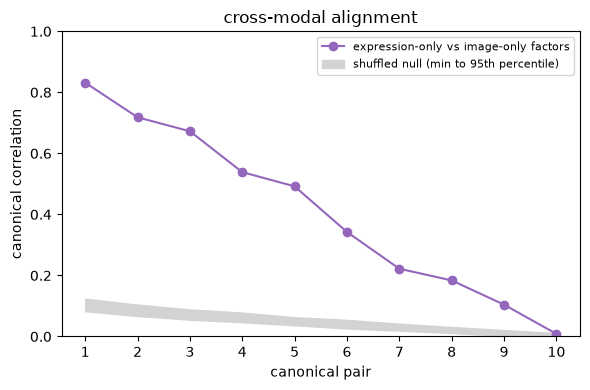

,1,2,3,4,5,6,7,8,9,10
canonical correlation,0.83,0.72,0.67,0.54,0.49,0.34,0.22,0.18,0.10,0.01
null 95th percentile,0.12,0.10,0.09,0.08,0.06,0.05,0.04,0.03,0.02,0.01


In [21]:
def canonical_correlations(a, b):
    qa, _ = np.linalg.qr(a - a.mean(axis=0))
    qb, _ = np.linalg.qr(b - b.mean(axis=0))
    return np.linalg.svd(qa.T @ qb, compute_uv=False)


a, b = F["rna_only"].to_numpy(), F["img_only"].to_numpy()
cc = canonical_correlations(a, b)
rng = np.random.default_rng(0)
null = np.array([canonical_correlations(a, b[rng.permutation(len(b))]) for _ in range(200)])

fig, ax = plt.subplots(figsize=(6, 4))
ranks = np.arange(1, len(cc) + 1)
ax.plot(ranks, cc, "o-", color="tab:purple", label="expression-only vs image-only factors")
ax.fill_between(ranks, null.min(axis=0), np.quantile(null, 0.95, axis=0), color="lightgrey", label="shuffled null (min to 95th percentile)")
ax.set(xlabel="canonical pair", ylabel="canonical correlation", ylim=(0, 1), xticks=ranks, title="cross-modal alignment")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

pd.DataFrame({"canonical correlation": cc, "null 95th percentile": np.quantile(null, 0.95, axis=0)}, index=ranks).round(2).T

This is the strongest evidence that the two views see related structure. The leading canonical correlation between the expression-only and image-only factor sets is 0.83, and five pairs exceed 0.49, while the shuffled null's 95th percentile never rises above 0.12. Fitted entirely apart, the two modalities arrive at several of the same axes.

The caveat above still applies: both factor sets are spatially smooth, and shuffling spots destroys that smoothness, so the null is lenient. A stricter null would preserve spatial structure — for example rotating or shifting the tissue — and would put the bar higher than 0.12.

### 5.4 Does the joint model keep what each view found alone?

Regress each factor of a single-view model on all ten joint factors. R² near 1: the joint model
contains that axis. Near 0: fitting the views together lost it.

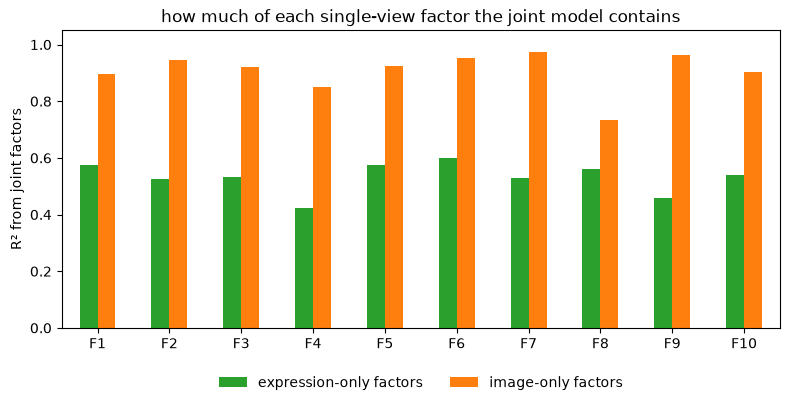

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
expression-only factors,0.58,0.53,0.53,0.42,0.57,0.60,0.53,0.56,0.46,0.54
image-only factors,0.90,0.94,0.92,0.85,0.92,0.95,0.97,0.73,0.96,0.90


In [22]:
def recovery(separate, joint):
    X = joint.to_numpy()
    return pd.Series({f: LinearRegression().fit(X, separate[f]).score(X, separate[f]) for f in separate.columns})


rec = pd.DataFrame({"expression-only factors": recovery(F["rna_only"], F["joint"]), "image-only factors": recovery(F["img_only"], F["joint"])})
ax = rec.plot.bar(figsize=(8, 4.2), rot=0, color=["tab:green", "tab:orange"])
ax.set(ylabel="R² from joint factors", ylim=(0, 1.05), title="how much of each single-view factor the joint model contains")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()
rec.round(2).T

The joint model contains the image-only factors almost completely (R² 0.73–0.97, most above 0.90) and the expression-only factors only in part (0.42–0.60).

Combined with §5.1, the direction is consistent: the joint factors sit closer to what the image view would have chosen on its own. If you need the expression factors themselves, fit expression on its own and use the joint model for the comparison.

### 5.5 Library size, mitochondria and spatial smoothness

Every factor, in every model, against log library size and % mitochondrial counts (Spearman ρ).
§3 showed both follow anatomy, so a strong correlation does not prove a factor is technical — but
a "shared" factor that is mostly library size has not found morphology.

The last column is each factor's Moran's I on the 6-nearest-spot graph: how smooth it is on the
tissue. It is the check we use instead of scoring factors against `cluster`, which is itself
derived from expression.

In [23]:
rows = []
for name, scores in F.items():
    for f in scores.columns:
        adata.obs[f"{name}_{f}"] = scores[f].to_numpy()
        rows.append(
            {
                "model": name,
                "factor": f,
                "R² expression": R2[name]["rna"].get(f, np.nan) if "rna" in R2[name] else np.nan,
                "R² image": R2[name]["img"].get(f, np.nan) if "img" in R2[name] else np.nan,
                "ρ log library size": spearmanr(scores[f], adata.obs["log10_library_size"])[0],
                "ρ % mito": spearmanr(scores[f], adata.obs["pct_mito"])[0],
            }
        )
summary = pd.DataFrame(rows)

factor_cols = [f"{r.model}_{r.factor}" for r in summary.itertuples()]
moran = sq.gr.spatial_autocorr(adata, mode="moran", attr="obs", genes=factor_cols, n_perms=None, copy=True, show_progress_bar=False)
summary["Moran's I"] = moran.loc[factor_cols, "I"].to_numpy()
summary.loc[summary["model"] == "joint", "kind"] = classify(R2["joint"]).to_numpy()
adata.obs = adata.obs.drop(columns=factor_cols)

summary.set_index(["model", "factor"]).round(2)

R² expression  R² image  ρ log library size  ρ % mito  \
model          factor                                                          
joint          F1               0.08      0.04               -0.64      0.33   
               F2               0.03      0.08               -0.12     -0.11   
               F3               0.02      0.09               -0.16      0.18   
               F4               0.04      0.07               -0.25      0.34   
               F5               0.03      0.08               -0.00      0.03   
               F6               0.05      0.05               -0.16     -0.04   
               F7               0.04      0.06                0.22      0.08   
               F8               0.00      0.09               -0.07      0.15   
               F9               0.02      0.07                0.14     -0.28   
               F10              0.02      0.07               -0.01      0.23   
joint_shuffled F1               0.06      0.05               -0.14     -0.13   
               F2               0.01      0.09                0.16     -0.05   
               F3               0.03      0.07               -0.09     -0.07   
               F4               0.03      0.06                0.08      0.13   
               F5               0.01      0.08                0.22     -0.14   
               F6               0.05      0.04               -0.30      0.07   
               F7               0.02      0.06                0.27     -0.11   
               F8               0.00      0.08               -0.02     -0.03   
               F9               0.01      0.07                0.13     -0.02   
               F10              0.00      0.07               -0.03     -0.02   
rna_only       F1               0.06       NaN                0.10     -0.00   
               F2               0.05       NaN                0.09     -0.41   
               F3               0.05       NaN                0.51     -0.30   
               F4               0.05       NaN                0.31      0.06   
               F5               0.05       NaN               -0.57      0.25   
               F6               0.05       NaN               -0.16      0.51   
               F7               0.05       NaN               -0.00     -0.13   
               F8               0.05       NaN               -0.39      0.19   
               F9               0.05       NaN               -0.01      0.23   
               F10              0.04       NaN                0.53     -0.40   
img_only       F1                NaN      0.09               -0.15     -0.13   
               F2                NaN      0.08               -0.29      0.25   
               F3                NaN      0.08               -0.14      0.15   
               F4                NaN      0.08               -0.04      0.15   
               F5                NaN      0.07                0.07      0.05   
               F6                NaN      0.07               -0.09      0.07   
               F7                NaN      0.07               -0.48      0.32   
               F8                NaN      0.07               -0.11      0.08   
               F9                NaN      0.06               -0.04     -0.10   
               F10               NaN      0.06               -0.04      0.28   

                       Moran's I            kind  
model          factor                             
joint          F1           0.55          shared  
               F2           0.68          shared  
               F3           0.60          shared  
               F4           0.80          shared  
               F5           0.80          shared  
               F6           0.72          shared  
               F7           0.61          shared  
               F8           0.44  image-specific  
               F9           0.68          shared  
               F10          0.73          shared  
joint_shuffled F1           0.33             NaN  

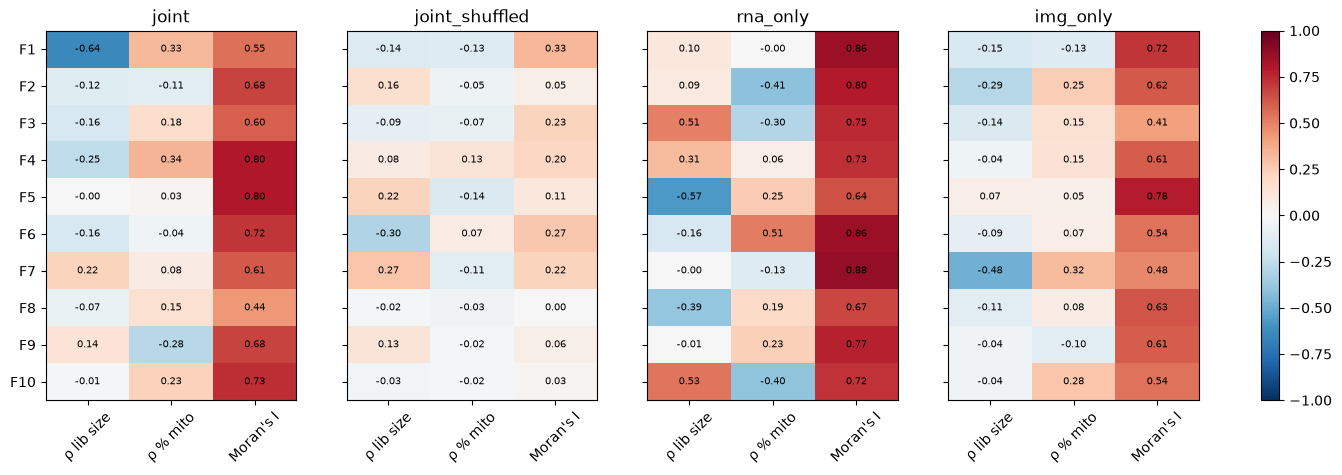

In [24]:
fig, axs = plt.subplots(1, 4, figsize=(16, 4.8), sharey=True)
for ax, name in zip(axs, F):
    s = summary[summary["model"] == name].set_index("factor")[["ρ log library size", "ρ % mito", "Moran's I"]]
    im = ax.imshow(s.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set(xticks=range(3), xticklabels=["ρ lib size", "ρ % mito", "Moran's I"], yticks=range(len(s)), yticklabels=s.index, title=name)
    ax.tick_params(axis="x", rotation=45)
    for (i, j), v in np.ndenumerate(s.to_numpy()):
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7)
plt.colorbar(im, ax=axs, fraction=0.02)
plt.show()

Two columns to check before trusting any factor, and one that turns out to separate real structure from the null.

- **Library size.** Joint F1 has ρ = −0.64 with log library size, the largest of any joint factor, and it is also the factor that explains the most expression variance. It is not a clean biological axis. Expression-only factors are no better: F5 (−0.57), F10 (0.53), F3 (0.51) and F8 (−0.39). Depth normalisation did not remove depth, which is what §3 predicted on a section where library size follows anatomy.
- **Mitochondrial fraction** is milder, peaking at ρ = 0.51 for one expression-only factor and 0.33–0.34 for joint F1 and F4.
- **Moran's I** does the job the R² threshold could not. Every joint factor is spatially smooth (0.44–0.80), while the factors of the shuffled model are not (0.00–0.33, seven of them below 0.23). Real factors describe patches of tissue; factors fitted to shuffled image features do not, no matter how much variance they explain.

### 5.6 The top shared, expression-specific and image-specific factors

The strongest factor of each kind in the joint model: shared by the smaller of its two R²,
specific by its R² in its own view. For each, its map, its top genes, and the tiles at both ends.

In [25]:
kind = classify(R2["joint"])
r2 = R2["joint"]
picks = {}
for label, score in [("shared", r2[["rna", "img"]].min(axis=1)), ("expression-specific", r2["rna"]), ("image-specific", r2["img"])]:
    candidates = score[kind == label]
    picks[label] = candidates.idxmax() if len(candidates) else None
print(picks)

weights = models["joint"].get_weights(ordered=True)["rna"]
weights = weights if weights.shape[0] == models["joint"].n_factors else weights.T
weights.index = r2.index


def top_genes(factor, n=8):
    w = weights.loc[factor].sort_values()
    return pd.DataFrame({"blue end (negative)": w.index[:n], "red end (positive)": w.index[::-1][:n]})


def extreme_tiles(factor, n=6, scores=None):
    s = (F["joint"] if scores is None else scores)[factor].to_numpy()
    idx = np.r_[np.argsort(s)[::-1][:n], np.argsort(s)[:n]]
    fig, axs = plt.subplots(2, n, figsize=(1.9 * n, 4.6))
    for ax, i in zip(axs.ravel(), idx):
        ax.imshow(tile(i))
        ax.set_title(f"{adata.obs['cluster'].iloc[i].replace('_', ' ')}\n{s[i]:+.2f}", fontsize=7)
        ax.axis("off")
    axs[0, 0].text(-0.2, 0.5, "red end", transform=axs[0, 0].transAxes, rotation=90, va="center", ha="right")
    axs[1, 0].text(-0.2, 0.5, "blue end", transform=axs[1, 0].transAxes, rotation=90, va="center", ha="right")
    plt.suptitle(f"{factor}: most extreme spots (expression cluster, factor score)", y=1.0)
    plt.tight_layout(h_pad=2)
    plt.show()


def factor_map(factor, table="mofa_joint", title=None, ax=None):
    show = ax is None
    if show:
        fig, ax = plt.subplots(figsize=(7, 6))
    sdata.pl.render_images("hne").pl.render_shapes("spots", color=factor, table_name=table, cmap="RdBu_r", norm=CenteredNorm(), fill_alpha=0.9).pl.show(
        ax=ax, title=title or factor, coordinate_systems="global"
    )
    zoom_to_tissue(ax)
    if show:
        plt.show()

{'shared': 'F6', 'expression-specific': None, 'image-specific': 'F8'}


#### Top shared factor

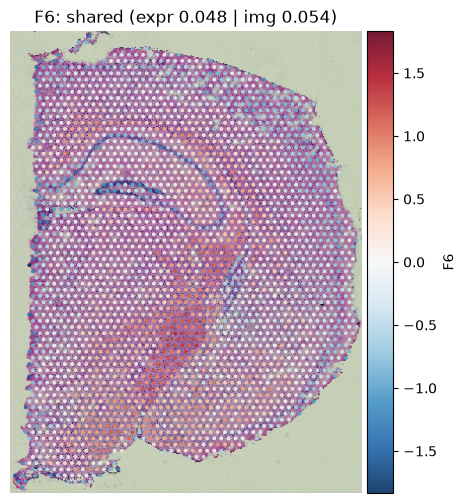

,blue end (negative),red end (positive)
0,Cck,Mbp
1,Slc17a7,Plp1
2,Nrgn,Mobp
3,Chn1,Pmch
4,Itpka,Mal
5,Zbtb18,Cnp
6,Camk2n1,Trf
7,Mef2c,Mag


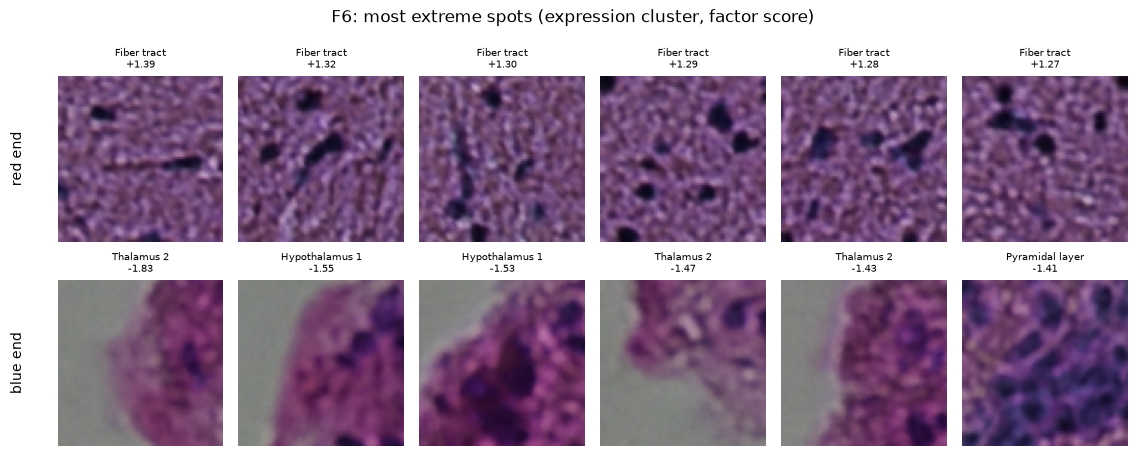

In [26]:
f = picks["shared"]
if f is None:
    print("no factor is active in both views at this threshold")
else:
    factor_map(f, title=f"{f}: shared (expr {r2.loc[f, 'rna']:.3f} | img {r2.loc[f, 'img']:.3f})")
    display(top_genes(f))
    extreme_tiles(f)

Is the shared factor something each view finds on its own? Below: the joint factor next to the
best-correlated factor of the expression-only and the image-only model, with signs flipped where
needed so all three point the same way.

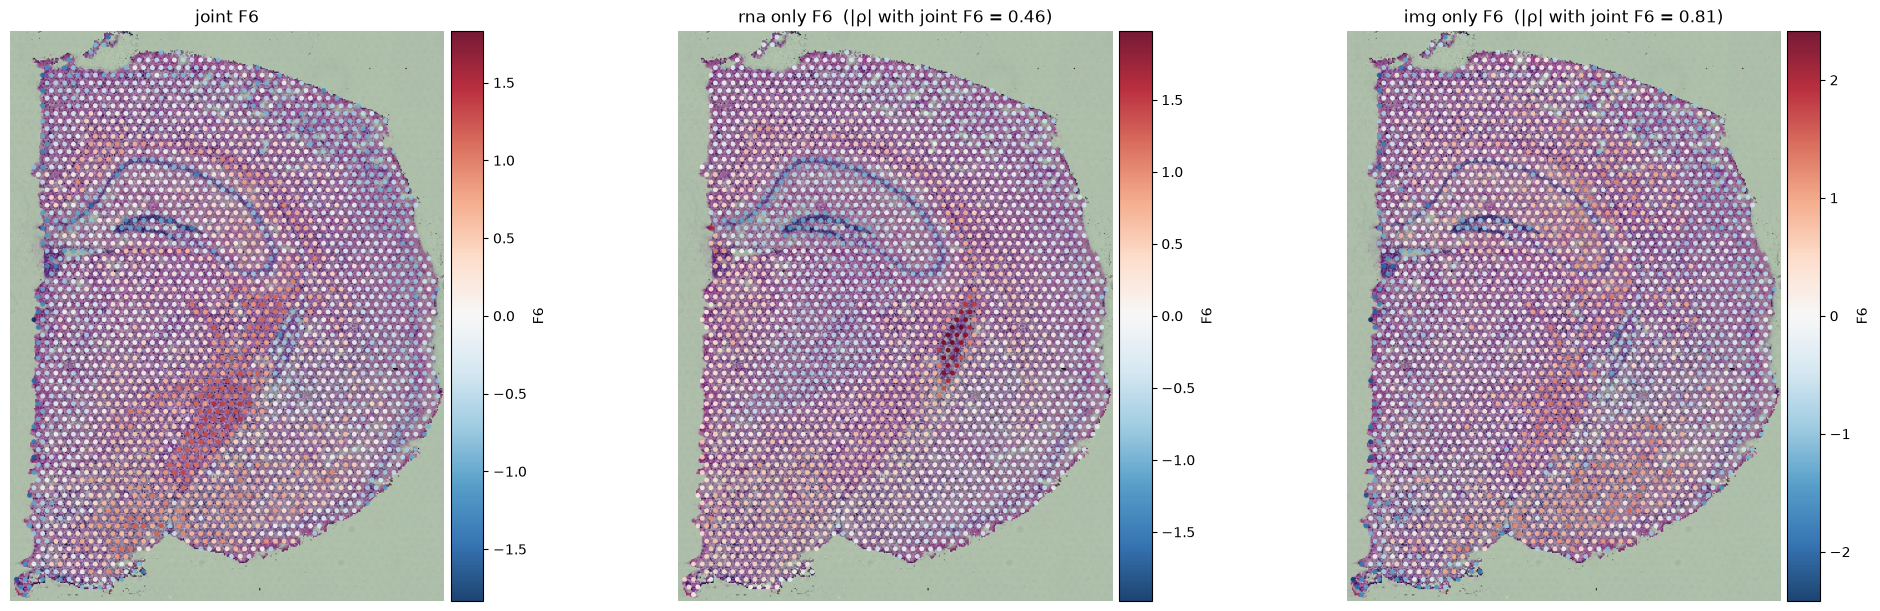

In [27]:
if picks["shared"] is not None:
    f = picks["shared"]
    aligned = {}
    for name in ["rna_only", "img_only"]:
        c = F[name].corrwith(F["joint"][f], method="spearman")
        best = c.abs().idxmax()
        add_factor_table(f"mofa_{name}_aligned", F[name] * np.sign(c))
        aligned[name] = (best, c[best])
    fig, axs = plt.subplots(1, 3, figsize=(20, 6), layout="constrained")
    factor_map(f, "mofa_joint", f"joint {f}", ax=axs[0])
    for ax, name in zip(axs[1:], ["rna_only", "img_only"]):
        best, rho = aligned[name]
        factor_map(best, f"mofa_{name}_aligned", f"{name.replace('_', ' ')} {best}  (|ρ| with joint {f} = {abs(rho):.2f})", ax=ax)
    plt.show()

F6 is white matter against neurons, and both modalities see it.

The red end carries the myelin programme — `Mbp`, `Plp1`, `Mobp`, `Mal`, `Cnp`, `Trf`, `Mag` — and all six of its most extreme tiles are fiber tract, with dark myelinated streaks crossing pale neuropil. The blue end carries neuronal genes (`Cck`, `Slc17a7`, `Nrgn`, `Camk2n1`, `Mef2c`). Its map traces the fiber tracts through the section. Moran's I is 0.72, and its correlation with library size is only −0.16, so this is not the depth axis.

Two honest qualifications. The blue-end tiles are mostly at the edge of the section and contain glass, and F6 correlates with the neighbour count at ρ = 0.44, so "interior versus edge" rides along with the biology. And the alignment panel shows the joint factor resembles the image-only factor (|ρ| = 0.81) more than the expression-only one (|ρ| = 0.46) — the same asymmetry as §5.4.

#### Top expression-specific factor

In [28]:
f = picks["expression-specific"]
if f is None:
    print("no expression-specific factor at this threshold")
else:
    factor_map(f, title=f"{f}: expression-specific (expr {r2.loc[f, 'rna']:.3f} | img {r2.loc[f, 'img']:.3f})")
    display(top_genes(f))
    extreme_tiles(f)

no expression-specific factor at this threshold


**There is no expression-specific factor.** Every joint factor that explains at least 1% of expression variance also clears 1% in the image.

Given §5.2, read that as a statement about the threshold rather than about biology: at this cut the shuffled model also produces "shared" factors, so "no expression-specific factor" mostly means the image view is active in all ten. The expression-specific structure has not disappeared — §5.4 shows the joint model keeps only 42–60% of each expression-only factor, so a good deal of it was not carried into the joint fit at all.

#### Top image-specific factor

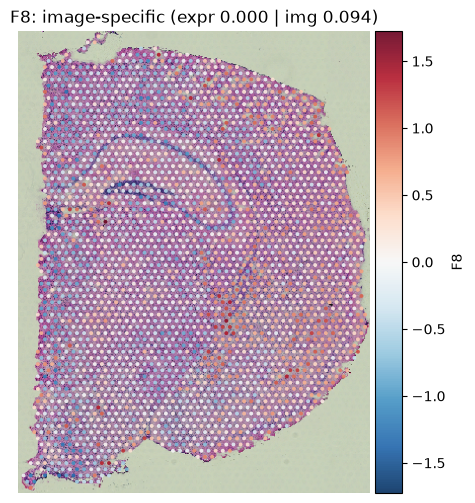

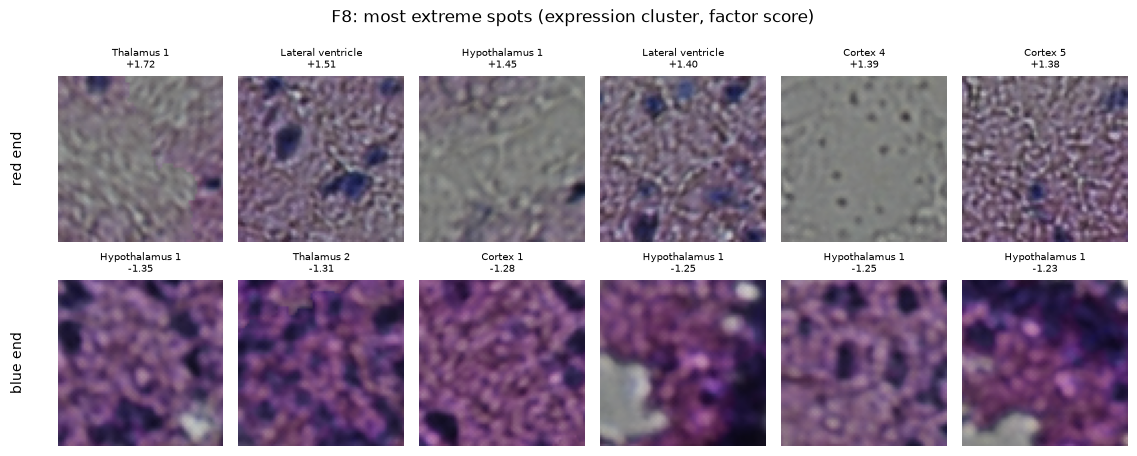

In [29]:
f = picks["image-specific"]
if f is None:
    print("no image-specific factor at this threshold")
else:
    factor_map(f, title=f"{f}: image-specific (expr {r2.loc[f, 'rna']:.3f} | img {r2.loc[f, 'img']:.3f})")
    extreme_tiles(f)

F8 explains 9.4% of the image variance and **0.0%** of the expression variance: the single factor that stands clearly outside the shuffled cloud on the image side.

Its extreme tiles differ in stain and contrast rather than in structure. The red end is pale and washed out, some tiles nearly featureless; the blue end is densely purple. They come from many different regions — thalamus, ventricle, hypothalamus, cortex — so this is not a tissue type. It correlates with x position (ρ = 0.48) and with tile sharpness (ρ = 0.37), and it has the lowest Moran's I of any joint factor (0.44), meaning it is the least tied to contiguous tissue.

That is the profile of a slide artefact: staining and focus drifting across the section. The exercise asks you to make this case yourself.

### Tools for telling tissue from slide

Image features respond to anything visible, including things that are not biology: where on the
slide a spot sits, how sharp the scan is there, how much empty glass is in the tile, and whether
the spot is at the edge of the section. The cell below measures each per spot and correlates it
with every joint factor (Spearman ρ).

In [30]:
from scipy.spatial import cKDTree

pixels = hne.transpose("y", "x", "c").values  # full-resolution image in memory, ~400 MB
h = CROP_PX // 2
grey = np.stack([pixels[y - h : y - h + CROP_PX, x - h : x - h + CROP_PX].mean(-1) for x, y in np.round(adata.obsm["spatial"]).astype(int)])
del pixels

tree = cKDTree(adata.obsm["spatial"])
spacing = tree.query(adata.obsm["spatial"], k=2)[0][:, 1].mean()

tile_stats = pd.DataFrame(
    {
        "x position": adata.obsm["spatial"][:, 0],
        "y position": adata.obsm["spatial"][:, 1],
        # mean absolute difference between neighbouring pixels: high for crisp texture, low for blur
        "sharpness": np.abs(np.diff(grey, axis=1)).mean((1, 2)) + np.abs(np.diff(grey, axis=2)).mean((1, 2)),
        "empty glass fraction": (grey > 200).mean((1, 2)),
        # spots within ~3 spot spacings: low at the edge of the section and next to holes
        "neighbours": [len(n) - 1 for n in tree.query_ball_point(adata.obsm["spatial"], 3.2 * spacing)],
        "log library size": adata.obs["log10_library_size"].to_numpy(),
    },
    index=adata.obs_names,
)

rho = pd.DataFrame({f: [spearmanr(F["joint"][f], tile_stats[c])[0] for c in tile_stats] for f in F["joint"].columns}, index=tile_stats.columns)
rho.round(2)

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
x position,-0.35,-0.48,-0.46,0.50,0.73,-0.08,0.36,0.48,0.05,-0.49
y position,-0.09,0.15,0.08,-0.29,-0.22,0.36,0.37,0.06,0.19,-0.08
sharpness,-0.32,-0.52,-0.47,0.25,0.52,0.28,0.32,0.37,-0.21,-0.37
empty glass fraction,-0.11,-0.22,-0.20,0.13,0.16,-0.00,0.25,0.18,0.01,-0.12
neighbours,-0.14,-0.07,0.03,-0.10,0.07,0.44,-0.15,-0.06,-0.38,0.03
log library size,-0.64,-0.12,-0.16,-0.25,-0.00,-0.16,0.22,-0.07,0.14,-0.01


## Exercise

Take the image-specific factor from §5.6 (or, if there is none, the factor with the highest
image R² and lowest expression R²) and decide whether it is **biology** or **the slide** —
tissue folds, tears, edge effects, staining or scanning variation. Build your case from:

1. its map on the tissue — does it follow anatomy, or the edge of the section?
2. the extreme tiles — what do the red-end tiles have in common that the blue-end tiles do not?
3. its column in the table above — position, sharpness, glass, edge, library size
4. its Moran's I and its R² in expression (§5.5)

Then answer: would you keep this factor in a downstream analysis? What would change your mind?

In [31]:
# your analysis here

<details>
<summary><b>One way to argue it</b> (open after trying)</summary>

**F8 is the slide, not the tissue.** The case:

1. **Expression says nothing about it.** R² in expression is 0.000. Whatever varies here leaves no transcriptional trace, in a section where even library size has one.
2. **Its tiles differ in stain, not in structure.** The red end is pale and low-contrast, the blue end densely purple, and both ends draw from thalamus, hypothalamus, ventricle and cortex alike.
3. **It tracks the slide.** ρ = 0.48 with x position and 0.37 with tile sharpness. Staining and focus drift across a section; biology does not drift with the scan axis.
4. **It is the least spatially coherent joint factor.** Moran's I 0.44, against 0.80 for the anatomical factors.

**Would you keep it?** Not as biology. It is still useful to keep *modelled*: an artefact that has its own factor is an artefact that is not contaminating the others. Dropping the factor without removing its cause would push that variance back into the rest.

**What would change the verdict?** A second section, stained and scanned separately, in which the same axis reappears in the same anatomy. That would make it biology the transcriptome happens to miss. As it stands, one section cannot separate "pale tissue" from "pale staining".

</details>

## What to take away

- The H&E image is a second measurement of the same tissue. A pathology foundation model turns
  it into features without any labels.
- Normalisation is a modelling decision. On Visium, library size follows anatomy, so check
  factors against it instead of assuming normalisation removed it.
- A multi-view factor model separates what the modalities share from what each has alone. Read
  the R² table first, and compare against a shuffled view before calling anything shared.
- Image-only signal is where artefacts live. Decide what a factor is from maps, tiles and simple
  image statistics before using it.